In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import fowlkes_mallows_score, adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
#LOADING THE DATA IN

data = load_breast_cancer()

data_frame = pd.DataFrame(data.data, columns = data.feature_names)

#1 = benign, 0 = malignant
data_frame['target'] = data.target

print(f"dataset shape: {data_frame.shape}")
data_frame.head() #outputting polished table, easier to read

dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


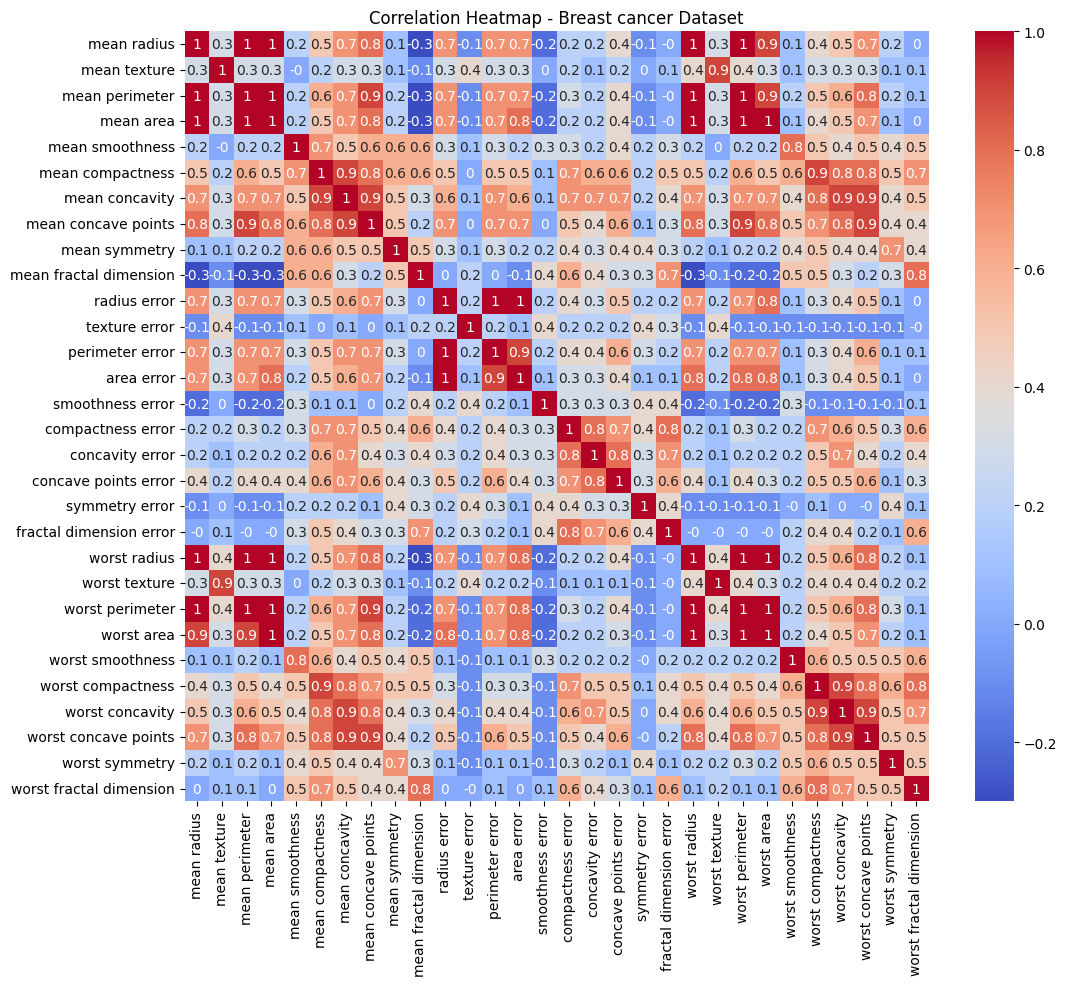

In [3]:
feature_names = data.feature_names

# Create a pandas DataFrame from the Breast cancer dataset
df = pd.DataFrame(data.data, columns=feature_names)

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(np.round(corr_matrix,1), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Breast cancer Dataset')
plt.show()

/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


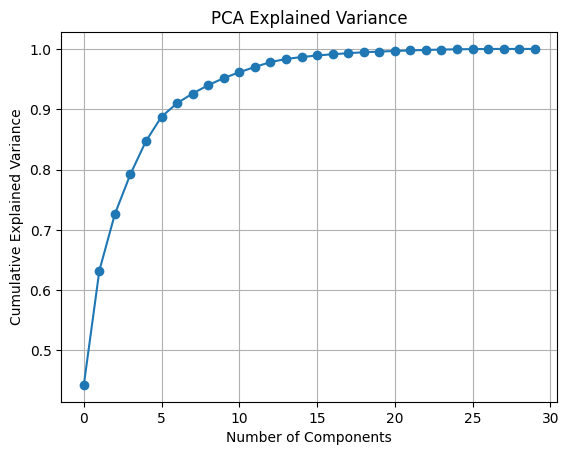

In [4]:
# Standardize (VERY important for PCA)
scaler = StandardScaler()
X = data_frame.drop(columns=["target"])
y = data_frame["target"]
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(X_scaled)

# Plot cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()



In [5]:
# PCA PREPROCESSING

# Number of principal components
n_components = 8

# 1. Standardize the feature data
X = data.data
y = data.target


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Compute covariance matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

# 3. Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# 4. Sort eigenvalues/eigenvectors in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_idx]
sorted_eigenvectors = eigenvectors[:, sorted_idx]

# 5. Select top principal components
top_components = sorted_eigenvectors[:, :n_components]

# 6. Project the data
projected_data = X_scaled @ top_components

# 7. Create dataframe of principal components
pc_columns = [f"PC{i+1}" for i in range(n_components)]
proj_data_frame = pd.DataFrame(projected_data, columns=pc_columns)

# 8. Add target labels
# sklearn breast cancer dataset uses:
# 0 = malignant, 1 = benign
proj_data_frame["target"] = y

# 9. Explained variance info
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
selected_variance = explained_variance_ratio[:n_components]
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"Projected dataset shape: {proj_data_frame.shape}")
print()

for i in range(n_components):
    print(f"PC{i+1} explained variance: {selected_variance[i]:.4f}")

print()
print(f"Cumulative explained variance for {n_components} PCs: {cumulative_variance[n_components - 1]:.4f}")
print()

proj_data_frame

Projected dataset shape: (569, 9)

PC1 explained variance: 0.4427
PC2 explained variance: 0.1897
PC3 explained variance: 0.0939
PC4 explained variance: 0.0660
PC5 explained variance: 0.0550
PC6 explained variance: 0.0402
PC7 explained variance: 0.0225
PC8 explained variance: 0.0159

Cumulative explained variance for 8 PCs: 0.9260



/var/folders/m4/x_z30xt16f9gl3jw2j79hfx80000gn/T/ipykernel_27772/3082015938.py:29: RuntimeWarning: divide by zero encountered in matmul
  projected_data = X_scaled @ top_components
/var/folders/m4/x_z30xt16f9gl3jw2j79hfx80000gn/T/ipykernel_27772/3082015938.py:29: RuntimeWarning: overflow encountered in matmul
  projected_data = X_scaled @ top_components
/var/folders/m4/x_z30xt16f9gl3jw2j79hfx80000gn/T/ipykernel_27772/3082015938.py:29: RuntimeWarning: invalid value encountered in matmul
  projected_data = X_scaled @ top_components


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,target
0,-9.192837,-1.948583,1.123166,-3.633731,-1.195110,-1.411424,-2.159370,-0.398407,0
1,-2.387802,3.768172,0.529293,-1.118264,0.621775,-0.028656,-0.013358,0.240988,0
2,-5.733896,1.075174,0.551748,-0.912083,-0.177086,-0.541452,0.668166,0.097374,0
3,-7.122953,-10.275589,3.232790,-0.152547,-2.960878,-3.053422,-1.429911,1.059565,0
4,-3.935302,1.948072,-1.389767,-2.940639,0.546747,1.226495,0.936213,0.636376,0
...,...,...,...,...,...,...,...,...,...
564,-6.439315,3.576817,-2.459487,-1.177314,-0.074824,2.375193,0.596130,-0.035471,0
565,-3.793382,3.584048,-2.088476,2.506028,-0.510723,0.246710,0.716326,-1.113360,0
566,-1.256179,1.902297,-0.562731,2.089227,1.809991,0.534447,0.192758,0.341887,0
567,-10.374794,-1.672010,1.877029,2.356031,-0.033742,-0.567936,-0.223082,-0.280239,0


/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

k = 2
Inertia: 10333.5830
Silhouette Score: 0.3654

k = 3
Inertia: 8804.6994
Silhouette Score: 0.3332

k = 4
Inertia: 8010.2256
Silhouette Score: 0.3023



/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

k = 5
Inertia: 7316.2328
Silhouette Score: 0.1808

k = 6
Inertia: 6838.2746
Silhouette Score: 0.1712

k = 7
Inertia: 6318.3539
Silhouette Score: 0.1765

k = 8
Inertia: 6013.0194
Silhouette Score: 0.1687

k = 9
Inertia: 5645.2538
Silhouette Score: 0.1733

k = 10
Inertia: 5439.5143
Silhouette Score: 0.1626



/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

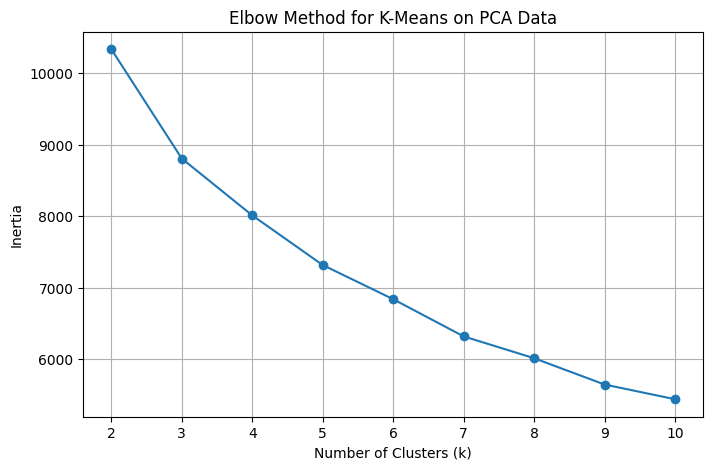

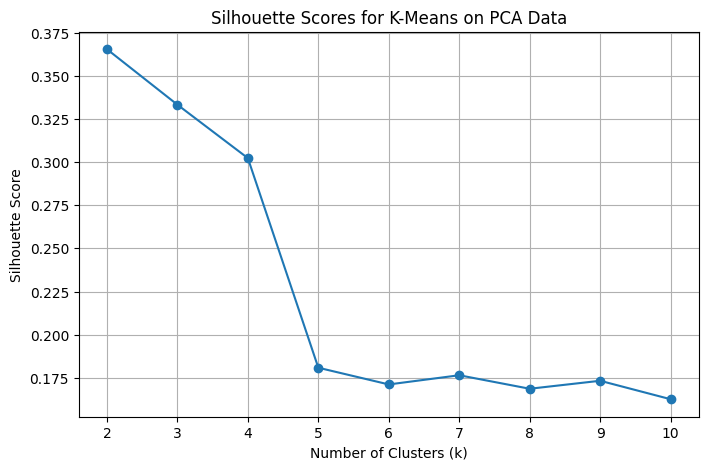

In [6]:
# ---------------------------
# K-MEANS ON PCA DATA
# ---------------------------

# Use only the PCA features, not the target column
X_kmeans = proj_data_frame.drop(columns=["target"])

inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_kmeans)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans, cluster_labels))

    print(f"k = {k}")
    print(f"Inertia: {kmeans.inertia_:.4f}")
    print(f"Silhouette Score: {silhouette_scores[-1]:.4f}")
    print()

# ---------------------------
# ELBOW PLOT
# ---------------------------
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means on PCA Data")
plt.grid(True)
plt.show()

# ---------------------------
# SILHOUETTE PLOT
# ---------------------------
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means on PCA Data")
plt.grid(True)
plt.show()

In [7]:
# ---------------------------
# FINAL K-MEANS MODEL OPTION 1 (k = 2)
# ---------------------------

best_k = 2
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
proj_data_frame["cluster"] = final_kmeans.fit_predict(X_kmeans)

proj_data_frame[["target", "cluster"]]

/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,target,cluster
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
564,0,1
565,0,1
566,0,1
567,0,1


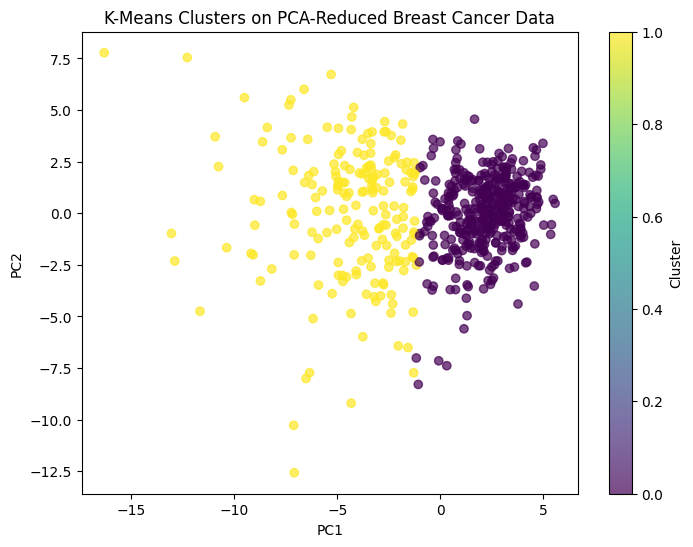

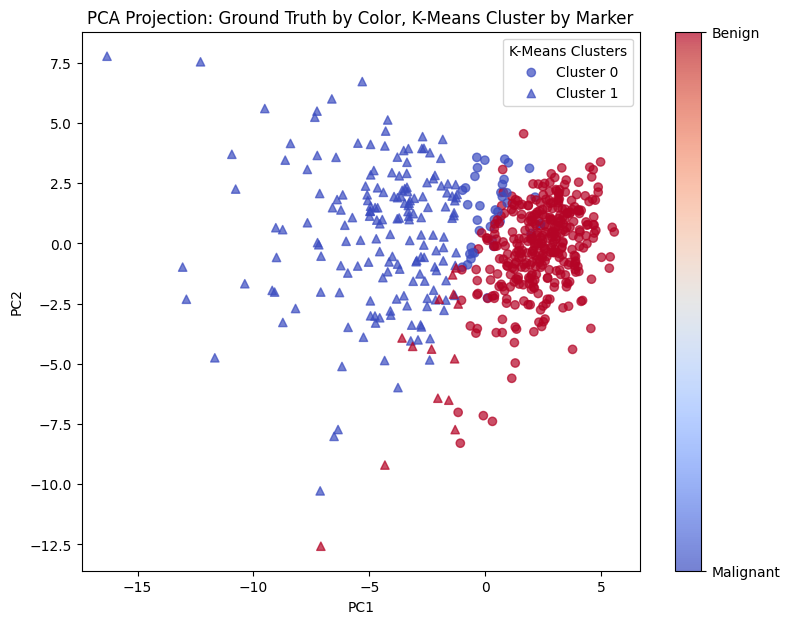

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(
    proj_data_frame["PC1"],
    proj_data_frame["PC2"],
    c=proj_data_frame["cluster"],
    cmap="viridis",
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-Reduced Breast Cancer Data")
plt.colorbar(label="Cluster")
plt.show()

plt.figure(figsize=(9, 7))

marker_map = {0: 'o', 1: '^', 2: 's', 3: 'D', 4: 'x', 5: '*'}

for cluster in sorted(proj_data_frame["cluster"].unique()):
    cluster_data = proj_data_frame[proj_data_frame["cluster"] == cluster]

    scatter = plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        c=cluster_data["target"],
        cmap="coolwarm",
        alpha=0.7,
        marker=marker_map[cluster],
        label=f"Cluster {cluster}"
    )

cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(["Malignant", "Benign"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection: Ground Truth by Color, K-Means Cluster by Marker")
plt.legend(title="K-Means Clusters")
plt.show()

In [9]:
# ---------------------------
# FINAL K-MEANS MODEL OPTION 1 (k = 3)
# ---------------------------

best_k = 3
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
proj_data_frame["cluster"] = final_kmeans.fit_predict(X_kmeans)

proj_data_frame[["target", "cluster"]]

/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,target,cluster
0,0,0
1,0,0
2,0,0
3,0,1
4,0,0
...,...,...
564,0,0
565,0,0
566,0,2
567,0,0


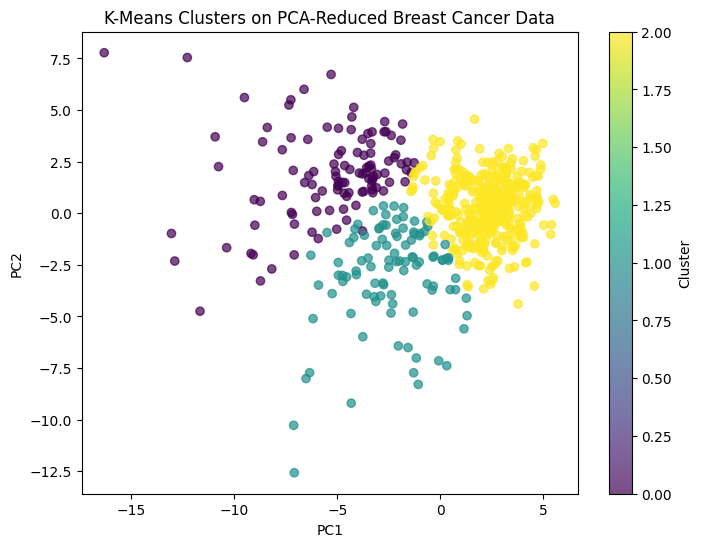

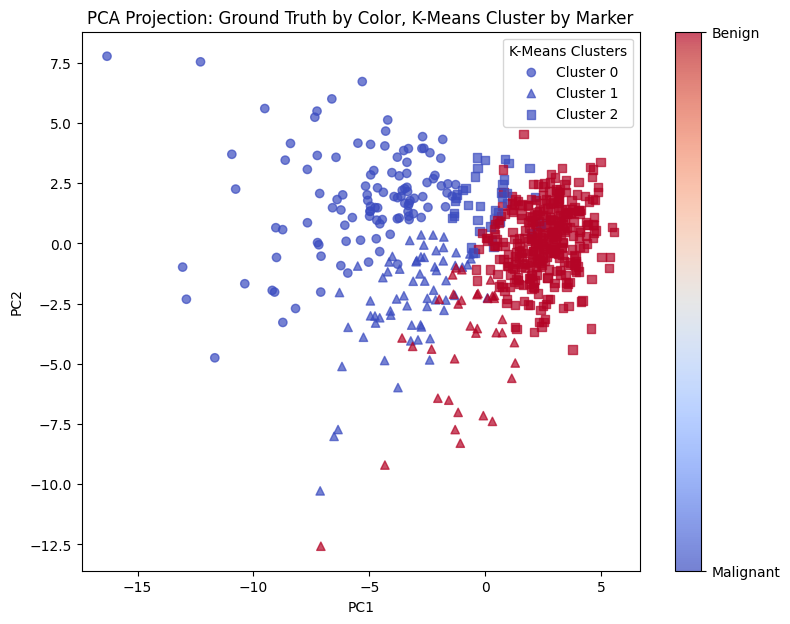

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    proj_data_frame["PC1"],
    proj_data_frame["PC2"],
    c=proj_data_frame["cluster"],
    cmap="viridis",
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-Reduced Breast Cancer Data")
plt.colorbar(label="Cluster")
plt.show()

plt.figure(figsize=(9, 7))

marker_map = {0: 'o', 1: '^', 2: 's', 3: 'D', 4: 'x', 5: '*'}

for cluster in sorted(proj_data_frame["cluster"].unique()):
    cluster_data = proj_data_frame[proj_data_frame["cluster"] == cluster]

    scatter = plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        c=cluster_data["target"],
        cmap="coolwarm",
        alpha=0.7,
        marker=marker_map[cluster],
        label=f"Cluster {cluster}"
    )

cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(["Malignant", "Benign"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection: Ground Truth by Color, K-Means Cluster by Marker")
plt.legend(title="K-Means Clusters")
plt.show()

In [17]:
# ---------------------------
# EVALUATION FUNCTION
# ---------------------------

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from scipy.stats import mode
import numpy as np

def evaluate_clustering(X, y, cluster_labels):
    
    print("----- INTERNAL METRICS -----")
    print("Silhouette Score:", silhouette_score(X, cluster_labels))
    print("Davies-Bouldin Index:", davies_bouldin_score(X, cluster_labels))
    print("Calinski-Harabasz Score:", calinski_harabasz_score(X, cluster_labels))
    
    print("\n----- EXTERNAL METRICS -----")
    print("ARI:", adjusted_rand_score(y, cluster_labels))
    print("NMI:", normalized_mutual_info_score(y, cluster_labels))

In [18]:
# ---------------------------
# EVALUATION FOR K = 2
# ---------------------------

kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X_kmeans)

evaluate_clustering(X_kmeans, y, labels_2)

----- INTERNAL METRICS -----
Silhouette Score: 0.3653798451218218
Davies-Bouldin Index: 1.2338759963335963
Calinski-Harabasz Score: 300.29819923110495

----- EXTERNAL METRICS -----
ARI: 0.6707206476880808
NMI: 0.5546122184105559


/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

In [19]:
# ---------------------------
# EVALUATION FOR K = 3
# ---------------------------

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(X_kmeans)

evaluate_clustering(X_kmeans, y, labels_3)

----- INTERNAL METRICS -----
Silhouette Score: 0.3332309265734024
Davies-Bouldin Index: 1.4229048183513135
Calinski-Harabasz Score: 225.05206404437027

----- EXTERNAL METRICS -----
ARI: 0.510670959369618
NMI: 0.42229582618320705


/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aryan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
